# Do ML Trading Signals Learned by Gradient Boosting Remain Predictive When Market Regimes Change?

**Operational Research Question:** Does a LightGBM trading signal predicting five-day forward SPY returns exhibit different out-of-sample predictive performance in low- and high-volatility market regimes?

**Scope:** SPY, daily, LightGBM, 5-day forward return target, ~11 price/volume features, Low Vol vs High Vol regime, walk-forward validation, MAE / prediction correlation / directional hit rate.

---

## Week 1 — Day 1: Price và Return

**Học:** price, simple return.

**Output:** Load SPY data, calculate daily return, plot price, plot return.

**Recall:** Tại sao return hữu ích hơn raw price change?

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import yfinance as yf

plt.rcParams["figure.figsize"] = (11, 4)
pd.set_option("display.width", 120)

RANDOM_STATE = 42

In [2]:
# Load SPY daily data. Auto-adjusted OHLCV (splits/dividends baked into price).
raw = yf.download("SPY", start="2005-01-01", auto_adjust=True, progress=False)

# yfinance returns MultiIndex columns when downloading a single ticker in recent versions.
if isinstance(raw.columns, pd.MultiIndex):
    raw.columns = raw.columns.get_level_values(0)

df = raw[["Open", "High", "Low", "Close", "Volume"]].copy()
df.index.name = "Date"

print(df.shape)
df.head()

(5438, 5)


Price,Open,High,Low,Close,Volume
Date,,,,,
2005-01-03,82.024857,82.159813,80.904744,81.174652,55748000
2005-01-04,81.282595,81.336577,79.919565,80.182724,69167600
2005-01-05,80.121926,80.466059,79.622600,79.629349,65667300
2005-01-06,79.919547,80.398631,79.798088,80.034256,47814700
2005-01-07,80.277182,80.452623,79.710374,79.919556,55847700


In [3]:
# Data quality check: missing values and duplicate dates
print("Missing values per column:")
print(df.isna().sum())

print("\nDuplicate dates:", df.index.duplicated().sum())

# Trading-day gaps: flag jumps > 5 calendar days (long weekends/holidays are normal;
# anything bigger may indicate a real gap in the feed).
gap_days = df.index.to_series().diff().dt.days
large_gaps = gap_days[gap_days > 5]
print(f"\nGaps > 5 calendar days: {len(large_gaps)}")
if len(large_gaps) > 0:
    print(large_gaps.tail(10))

Missing values per column:
Price
Open      0
High      0
Low       0
Close     0
Volume    0
dtype: int64

Duplicate dates: 0

Gaps > 5 calendar days: 0


In [4]:
# Simple daily return: r_t = P_t / P_{t-1} - 1
df["Return1"] = df["Close"].pct_change()

df[["Close", "Return1"]].tail()

Price,Close,Return1
Date,,
2026-08-10,773.030029,-0.000297
2026-08-11,770.559998,-0.003195
2026-08-12,772.489990,0.002505
2026-08-13,777.880005,0.006977
2026-08-14,776.340027,-0.001980


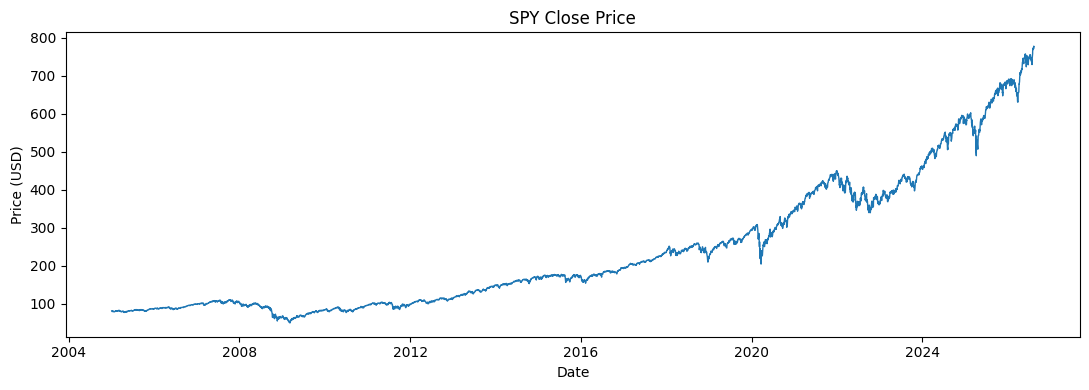

In [5]:
fig, ax = plt.subplots()
ax.plot(df.index, df["Close"], color="#1f77b4", linewidth=1)
ax.set_title("SPY Close Price")
ax.set_xlabel("Date")
ax.set_ylabel("Price (USD)")
plt.tight_layout()
plt.show()

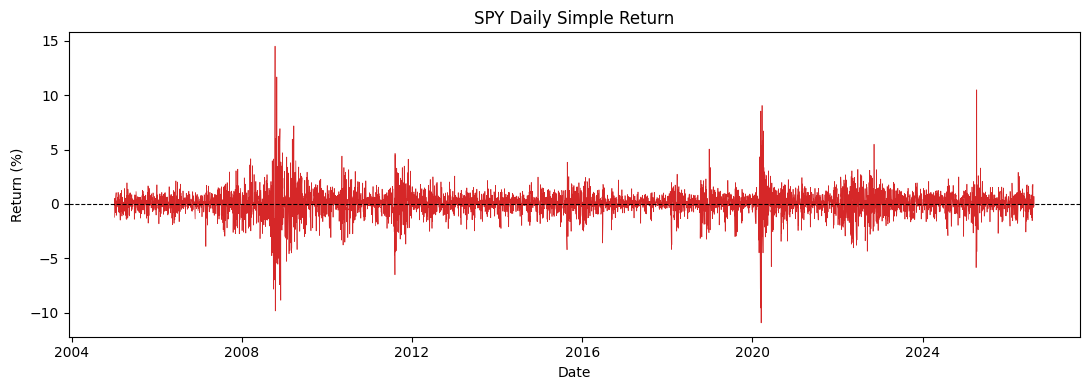

In [6]:
fig, ax = plt.subplots()
ax.plot(df.index, df["Return1"] * 100, color="#d62728", linewidth=0.5)
ax.axhline(0, color="black", linewidth=0.8, linestyle="--")
ax.set_title("SPY Daily Simple Return")
ax.set_xlabel("Date")
ax.set_ylabel("Return (%)")
plt.tight_layout()
plt.show()

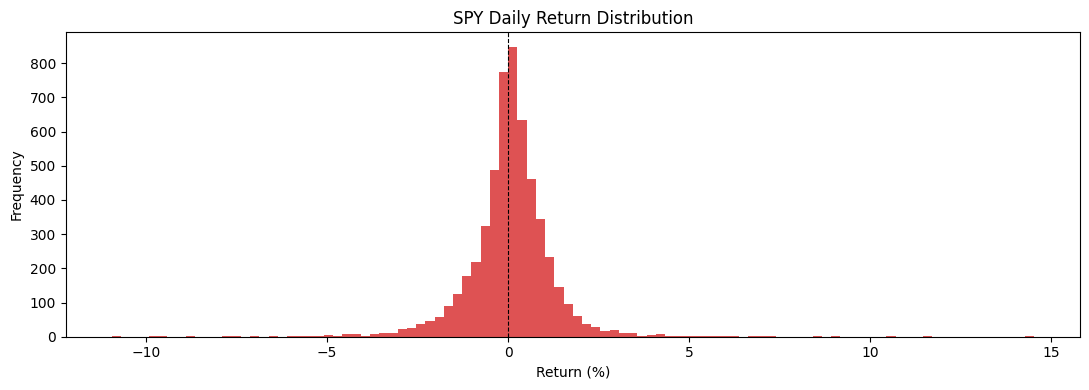

In [7]:
# Distribution of daily returns
fig, ax = plt.subplots()
ax.hist(df["Return1"].dropna() * 100, bins=100, color="#d62728", alpha=0.8)
ax.axvline(0, color="black", linewidth=0.8, linestyle="--")
ax.set_title("SPY Daily Return Distribution")
ax.set_xlabel("Return (%)")
ax.set_ylabel("Frequency")
plt.tight_layout()
plt.show()

In [8]:
# Summary statistics in percent
(df["Return1"] * 100).describe().to_frame(name="Return1 (%)").round(3)

,Return1 (%)
count,5437.000
mean,0.049
std,1.192
min,-10.942
25%,-0.393
50%,0.072
75%,0.582
max,14.520


### Recall: Tại sao return hữu ích hơn raw price change?

- **Chuẩn hóa theo tỷ lệ.** $10 tăng trên giá $100 (10%) khác hẳn $10 tăng trên giá $1000 (1%). Raw price change không phân biệt được hai trường hợp này; return thì có.
- **Gần với câu hỏi thực tế**: "Capital thay đổi bao nhiêu phần trăm?" — đây mới là thứ nhà đầu tư quan tâm, không phải số USD tuyệt đối.
- **So sánh được giữa các tài sản/thời điểm khác nhau.** Vì price level của SPY thay đổi rất nhiều qua 20 năm (từ ~$120 lên ~$550+), dùng raw price change sẽ khiến các giai đoạn có price level cao "trông" biến động mạnh hơn một cách giả tạo. Return loại bỏ bias này.
- **Thống kê ổn định hơn.** Return có xu hướng ở gần một phân phối ổn định quanh 0 (stationary hơn price), phù hợp hơn để làm input cho model học máy so với giá tuyệt đối vốn có trend dài hạn.

---

**Tiếp theo → Day 2: Forward Return.**

---

## Preview: Feature Set (Section 8 trong tài liệu)

Trước khi đi tiếp theo thứ tự Day 2–6, xem trước toàn bộ ~11 features sẽ dùng làm input cho model, để hiểu hình dạng của chúng qua thời gian. Feature engineering "chính thức" (với leakage audit) sẽ quay lại ở Day 6–7.

Feature set:
- **Return/Momentum:** Return1, Return5, Return10, Return20
- **Volatility:** Vol5, Vol10, Vol20
- **Trend:** Trend10, Trend20, Trend60
- **Volume:** VolumeRatio

Tất cả đều chỉ dùng dữ liệu quá khứ tại thời điểm t (rolling window nhìn về trước) — không leakage.

In [9]:
# 8.1 Return / Momentum features: Return_N,t = P_t / P_{t-N} - 1
for n in [5, 10, 20]:
    df[f"Return{n}"] = df["Close"] / df["Close"].shift(n) - 1

# 8.2 Volatility features: rolling std of daily returns
for n in [5, 10, 20]:
    df[f"Vol{n}"] = df["Return1"].rolling(n).std()

# 8.3 Trend features: Trend_N,t = P_t / MA_N,t - 1
for n in [10, 20, 60]:
    ma = df["Close"].rolling(n).mean()
    df[f"Trend{n}"] = df["Close"] / ma - 1

# 8.4 Volume feature: VolumeRatio_t = Volume_t / MA20(Volume)_t
df["VolumeRatio"] = df["Volume"] / df["Volume"].rolling(20).mean()

FEATURE_COLS = [
    "Return1", "Return5", "Return10", "Return20",
    "Vol5", "Vol10", "Vol20",
    "Trend10", "Trend20", "Trend60",
    "VolumeRatio",
]
print(f"{len(FEATURE_COLS)} features built.")
df[FEATURE_COLS].tail()

11 features built.


Price,Return1,Return5,Return10,Return20,Vol5,Vol10,Vol20,Trend10,Trend20,Trend60,VolumeRatio
Date,,,,,,,,,,,
2026-08-10,-0.000297,0.020273,0.045921,0.031849,0.008471,0.010223,0.008821,0.020814,0.028834,0.035843,0.793230
2026-08-11,-0.003195,-0.000998,0.040089,0.024913,0.003676,0.010503,0.008872,0.013577,0.024270,0.031973,0.741328
2026-08-12,0.002505,0.003507,0.058989,0.023423,0.003675,0.008080,0.008855,0.010397,0.025630,0.033745,0.676748
2026-08-13,0.006977,0.012127,0.048794,0.036179,0.004282,0.007139,0.008801,0.012654,0.030927,0.040004,0.734907
2026-08-14,-0.001980,0.003983,0.039235,0.044465,0.004061,0.007382,0.008416,0.006807,0.026638,0.036917,0.667750


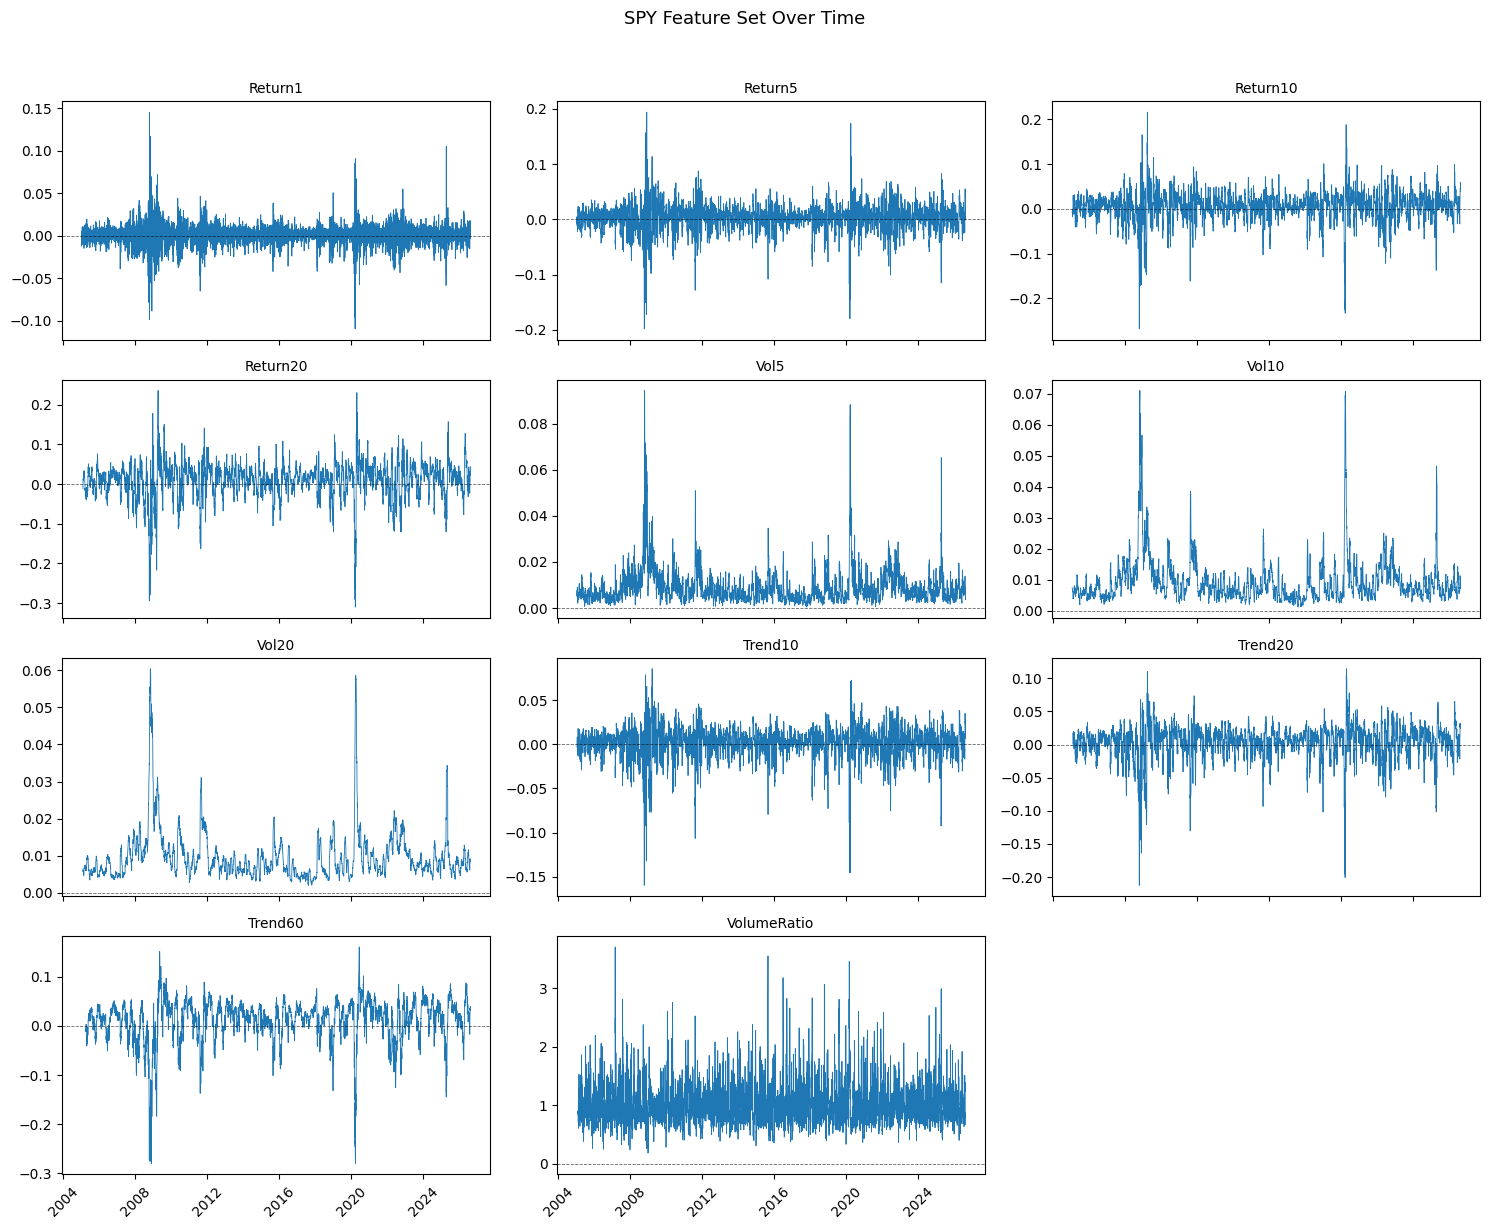

In [10]:
# Plot all features over time, one panel per feature
n_cols = 3
n_rows = int(np.ceil(len(FEATURE_COLS) / n_cols))

fig, axes = plt.subplots(n_rows, n_cols, figsize=(15, 3 * n_rows), sharex=True)
axes = axes.flatten()

for ax, col in zip(axes, FEATURE_COLS):
    ax.plot(df.index, df[col], linewidth=0.6, color="#1f77b4")
    ax.axhline(0, color="black", linewidth=0.6, linestyle="--", alpha=0.6)
    ax.set_title(col, fontsize=10)
    ax.tick_params(axis="x", rotation=45)

# Hide unused subplots (11 features in a 4x3 grid -> 1 empty)
for ax in axes[len(FEATURE_COLS):]:
    ax.set_visible(False)

fig.suptitle("SPY Feature Set Over Time", y=1.02, fontsize=13)
plt.tight_layout()
plt.show()